In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [ ]:
# Import data
niv = '3'

# HICP All Items
colHicp = "INX"

# Unchained other items 
dfICP = pd.read_parquet(f"input/EAunchainedItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/EAnormedWeightsLvl{niv}.parquet") 

In [12]:
# We compute inflation rates on Unchained items - 12-month inflation rate (deals mostly with seasonality) - monthly frequency
dfInflation = np.log(dfICP).diff(12)[12:]
InflTot = dfInflation["INX"].to_frame()
dfInflation = dfInflation.drop("INX",axis=1)

In [ ]:
def twoStepsAr(dfInflation, rolling_window=120):
    """2-steps AR(1) regressions (Lansing & Shapiro, 2026).

    dfInflation : DataFrame (Dates x Catégories) - Monthly 12-month inflation rate from unchained items
    """

    # Input
    categories = dfInflation.columns
    
    # Stockage temporaire des chocs (résidus de l'AR(1))
    shocks_dict = {cat: pd.Series(index=dfInflation.index, dtype=float) for cat in categories}
    a_dict = {cat: pd.Series(index=dfInflation.index, dtype=float) for cat in categories}
    rho_dict = {cat: pd.Series(index=dfInflation.index, dtype=float) for cat in categories}
    
    for t_idx in range(rolling_window, len(dfInflation)):
        current_date = dfInflation.index[t_idx]

        for cat in categories:
            # 120 month rolling window (Lansing & Shapiro, 2026)
            window_data = dfInflation[cat].iloc[t_idx - rolling_window : t_idx + 1]

            y = window_data.iloc[1:].values        # Inflation rate T
            x = window_data.iloc[:-1].values       # Inflation rate lagged (T-1)
            x = sm.add_constant(x)

            try:
                ### 2-step regressions (to get A and Rho coefficients)             
                #   1) Current inflation shock
                model1 = sm.OLS(y, x).fit()
                residuals = model1.resid
                shocks_dict[cat].at[current_date] = residuals[-1]
                
                # Inflation AR(1) coefficient (constant)
                a_dict[cat].at[current_date] = model1.params[1]
                
                #   2) AR(1) on OLS' residuals
                yRes = residuals[1:]        
                xRes = residuals[:-1]
                model2 = sm.OLS(yRes, xRes).fit()
                rho_dict[cat].at[current_date] = model2.params[0]
                
            except:
                a_dict[cat].at[current_date] = None
                rho_dict[cat].at[current_date] = None
                shocks_dict[cat].at[current_date] = None

    df_shocks = pd.DataFrame(shocks_dict)
    aCoef = pd.DataFrame(a_dict)
    rhoCoef = pd.DataFrame(rho_dict)
    
    return df_shocks, aCoef, rhoCoef


def replicateIsmi(dfInflation, df_shocks, dfW=dfW, rolling_window=120, k=3):
    """Replication of ISMI Index (Lansing & Shapiro, 2026).
    -------
    posItems : Positive ISMI contribution by component, weighted.
    negItems : Negative ISMI contribution by component, weighted.
    posIsmi  : Aggregate positive ISMI.
    negIsmi  : Aggregate negative ISMI.
    ismIndex : Total ISMI = positive - negative.
    """

    print(
        f"Step 1 : Estimate {len(dfInflation.columns)} AR(1) "
        f"on a {rolling_window} month rolling window..."
    )

    # Estimate shocks
    df_shocks, _, _ = twoStepsAr(
        dfInflation,
        rolling_window=rolling_window
    )

    # Dates for which we can calculate the index
    dates = df_shocks.index.intersection(dfW.index)

    ismIndex = []
    posIsmi = []
    negIsmi = []

    # Per components
    posItems = []
    negItems = []

    print("Step 2 : Compute inflation momentum and aggregate...")

    for current_date in dates:

        t_pos = df_shocks.index.get_loc(current_date)

        # K consecutive shocks
        recent_shocks = df_shocks.iloc[
            t_pos - k + 1 : t_pos + 1
        ]

        # Positive / negative momentum signal by component
        pos_signal = (recent_shocks > 0).all(axis=0).astype(int)

        neg_signal = (recent_shocks < 0).all(axis=0).astype(int)

        # Weights
        w = dfW.loc[current_date]

        # Weighted contribution by component
        share_pos = pos_signal * w
        share_neg = neg_signal * w

        # Store component-level contributions
        posItems.append(share_pos)
        negItems.append(share_neg)

        # Aggregate positive / negative ISMI
        pos = share_pos.sum()
        neg = share_neg.sum()

        posIsmi.append(pos)
        negIsmi.append(neg)

        # Total ISMI
        ismIndex.append(pos - neg)

    ### Convert to DataFrames
    dates = dates[rolling_window+k-1:]
    
    posItems = pd.DataFrame(
        posItems[rolling_window+k-1:],
        index=dates,
        columns=dfInflation.columns
    )

    negItems = pd.DataFrame(
        negItems[rolling_window+k-1:],
        index=dates,
        columns=dfInflation.columns
    )

    posIsmi = pd.Series(
        posIsmi[rolling_window+k-1:],
        index=dates,
        name="ISMI+"
    )

    negIsmi = pd.Series(
        negIsmi[rolling_window+k-1:],
        index=dates,
        name="ISMI-"
    )

    ismIndex = pd.Series(
        ismIndex[rolling_window+k-1:],
        index=dates,
        name="ISMIndex"
    )

    print("Done")

    return posItems, negItems, posIsmi, negIsmi, ismIndex

In [ ]:
# Call estimates
df_shocks, aCoef, rhoCoef = twoStepsAr(dfInflation, rolling_window=120)
posItems, negItems, posIsmi, negIsmi, ismIndex = replicateIsmi(dfInflation, df_shocks)

# Merge
ismIndex = ismIndex.to_frame().merge(
    InflTot,
    how="left",
    left_index=True,
    right_index=True)

Step 1 : Estimate 126 AR(1) on a 120 month rolling window...
Step 2 : Compute inflation momentum and aggregate...
Done


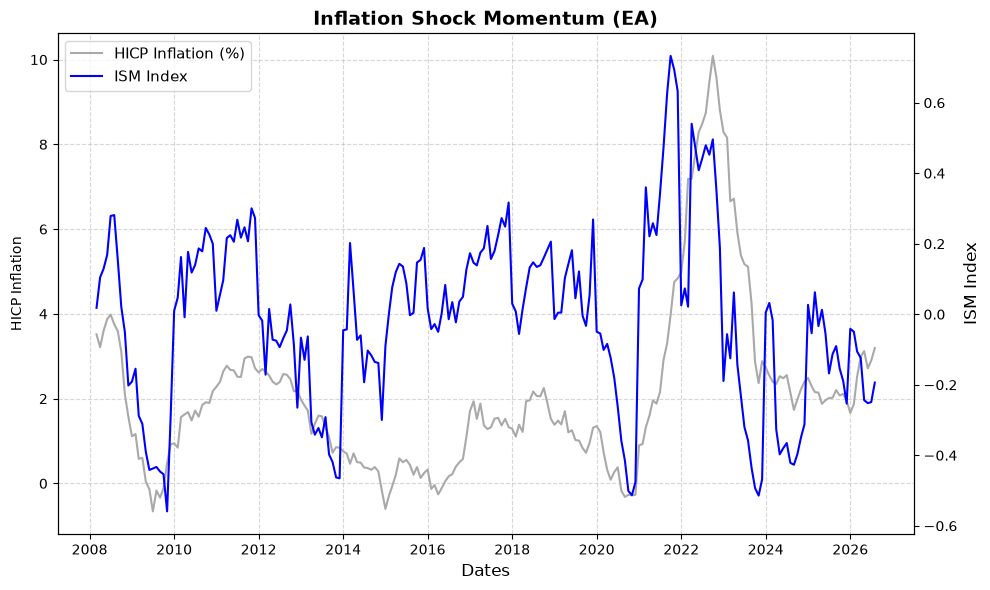

In [ ]:
# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (HICP inflation - 12-month) ---
ax1.plot(
    ismIndex["INX"]*100,
    label="HICP Inflation (%)",
    color="darkgrey",
    linewidth=1.5,
)

ax1.set_xlabel("Dates", fontsize=12)
ax1.set_ylabel("HICP Inflation")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Right axis (AR coefficients) ---
ax2 = ax1.twinx()

ax2.plot(
    ismIndex["ISMIndex"],
    label="ISM Index",
    color="blue",
    linewidth=1.5,
)

ax2.set_ylabel("ISM Index", fontsize=12)
ax2.tick_params(axis="y")

# --- Title, legend ---
plt.title("Inflation Shock Momentum (EA)", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=11)

plt.tight_layout()
plt.show()

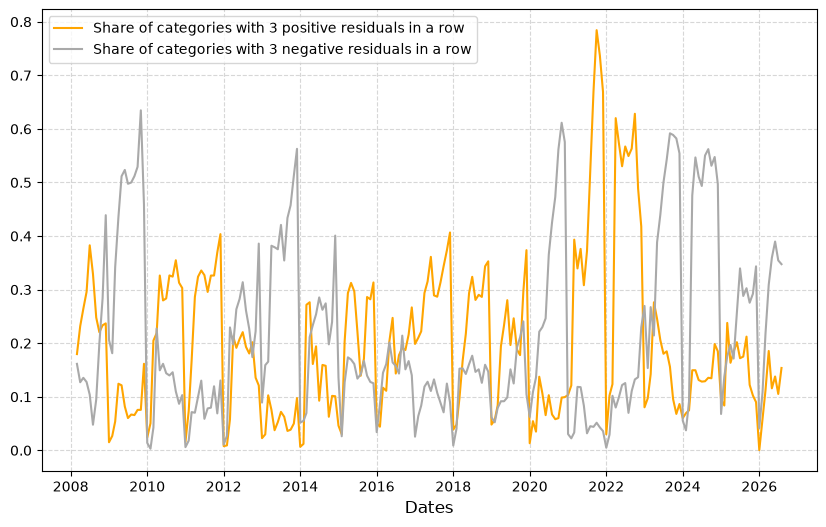

In [85]:
# Positive and negative contributions
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = posIsmi.index
ax.plot(
    x_axis,
    posIsmi.values,
    color="orange",
    label="Share of categories with 3 positive residuals in a row",
    linewidth=1.5,
)

ax.plot(
    x_axis,
    negIsmi.values,
    label="Share of categories with 3 negative residuals in a row",
    color="darkgrey",
    linewidth=1.5,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

In [ ]:
# Réplication Figure A1
df_shocks, aCoef, rhoCoef = twoStepsAr(InflTot)

# Drop NaN and merge
HICP = InflTot.copy()
HICP["Shocks"] = df_shocks.values
HICP["A"] = aCoef.values
HICP["Rho"] = rhoCoef.values
HICP = HICP.dropna()

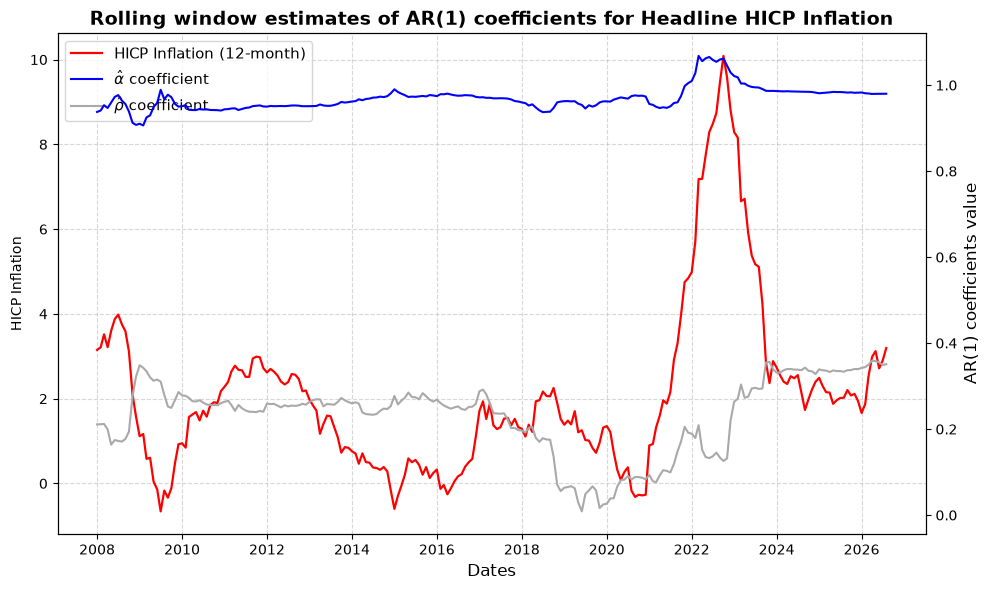

In [75]:
# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (HICP inflation - 12-month) ---
ax1.plot(
    HICP["INX"]*100,
    label="HICP Inflation (12-month)",
    color="red",
    linewidth=1.6,
)

ax1.set_xlabel("Dates", fontsize=12)
ax1.set_ylabel("HICP Inflation")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Right axis (AR coefficients) ---
ax2 = ax1.twinx()

ax2.plot(
    HICP["A"],
    label=r'$\hat \alpha$ coefficient',
    color="blue",
    linewidth=1.5,
)

ax2.plot(
    HICP["Rho"],
    label=r'$\hat \rho$ coefficient',
    color="darkgrey",
    linewidth=1.5,
)

ax2.set_ylabel("AR(1) coefficients value", fontsize=12)
ax2.tick_params(axis="y")

# --- Title, legend ---
plt.title("Rolling window estimates of AR(1) coefficients for Headline HICP Inflation", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)

plt.tight_layout()
plt.show()